# RNN vs LSTM vs GRU for Sequence Classification

## Deep Learning Practical

### Objective

To implement and compare Recurrent Neural Network (RNN), Long Short-Term Memory (LSTM), and Gated Recurrent Unit (GRU) models for sequence classification and analyze their performance using appropriate evaluation metrics.

## 1. Aim

To implement RNN, LSTM, and GRU deep learning models for binary sequence classification using the IMDB movie review dataset and compare their performance using accuracy, precision, recall, F1-score, confusion matrix, validation performance, training time, and number of parameters.

## 2. Objectives

1. Load and understand the IMDB movie review dataset.
2. Preprocess and prepare the sequential text data.
3. Convert variable-length sequences into fixed-length padded sequences.
4. Build an RNN-based sequence classification model.
5. Build an LSTM-based sequence classification model.
6. Build a GRU-based sequence classification model.
7. Train all three models using the same experimental configuration.
8. Evaluate the models using accuracy, precision, recall, and F1-score.
9. Analyze confusion matrices and training/validation curves.
10. Compare model complexity and training time.
11. Discuss the advantages and limitations of RNN, LSTM, and GRU architectures.

## 3. Theory

### 3.1 Sequence Classification

Sequence classification is a machine learning task in which the input consists of an ordered sequence and the objective is to assign a class label to the complete sequence.

For this experiment, the input is a movie review and the output is its sentiment:

- 0 → Negative
- 1 → Positive

### 3.2 Recurrent Neural Network (RNN)

A Recurrent Neural Network processes sequential data by maintaining a hidden state that carries information from previous time steps.

The hidden state can be represented as:

h_t = f(W_x x_t + W_h h_(t-1) + b)

A standard RNN can struggle to learn long-term dependencies because of vanishing or exploding gradients.

### 3.3 Long Short-Term Memory (LSTM)

LSTM is a type of recurrent neural network designed to handle long-term dependencies more effectively.

It uses a cell state and gating mechanisms:

- Forget gate
- Input gate
- Output gate

These gates regulate which information should be forgotten, stored, and passed to the next time step.

### 3.4 Gated Recurrent Unit (GRU)

GRU is another gated recurrent architecture.

It uses:

- Update gate
- Reset gate

GRU has a simpler structure than LSTM while still providing mechanisms for handling longer-term dependencies.

### 3.5 Embedding

An embedding layer converts integer word indices into dense numerical vectors. These vectors allow the neural network to learn useful representations of words.

### 3.6 Padding

Movie reviews have different sequence lengths. Padding converts them to a common fixed length so that they can be processed efficiently in batches.

## 4. Dataset

The IMDB Movie Reviews dataset is used for binary sentiment classification.

### Dataset characteristics

- Total reviews: 50,000
- Training reviews: 25,000
- Testing reviews: 25,000
- Number of classes: 2
- Class 0: Negative
- Class 1: Positive

The dataset is suitable for this experiment because movie reviews are naturally sequential text data.

### Import libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### Set random seeds

In [6]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


### Check hardware

In [7]:
print("Available GPUs:")

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    print(gpu)

if gpus:
    print("\nGPU is available.")
else:
    print("\nGPU is not available. Training will use CPU.")

Available GPUs:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU is available.


### Define experiment configuration

In [8]:
NUM_WORDS = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
HIDDEN_UNITS = 64

EPOCHS = 5
BATCH_SIZE = 128

print("Vocabulary size:", NUM_WORDS)
print("Maximum sequence length:", MAX_LEN)
print("Embedding dimension:", EMBEDDING_DIM)
print("Hidden units:", HIDDEN_UNITS)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Vocabulary size: 10000
Maximum sequence length: 200
Embedding dimension: 128
Hidden units: 64
Epochs: 5
Batch size: 128


### Load IMDB dataset

In [9]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=NUM_WORDS
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step 
Training samples: 25000
Testing samples: 25000


### Inspect the raw sequence

In [10]:
print("First review sequence:")
print(X_train[0])

print("\nFirst review label:")
print(y_train[0])

First review sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First review label:
1


### Analyze sequence lengths

In [11]:
train_lengths = [len(sequence) for sequence in X_train]

print("Minimum sequence length:", min(train_lengths))
print("Maximum sequence length:", max(train_lengths))
print("Average sequence length:", np.mean(train_lengths))
print("Median sequence length:", np.median(train_lengths))

Minimum sequence length: 11
Maximum sequence length: 2494
Average sequence length: 238.71364
Median sequence length: 178.0


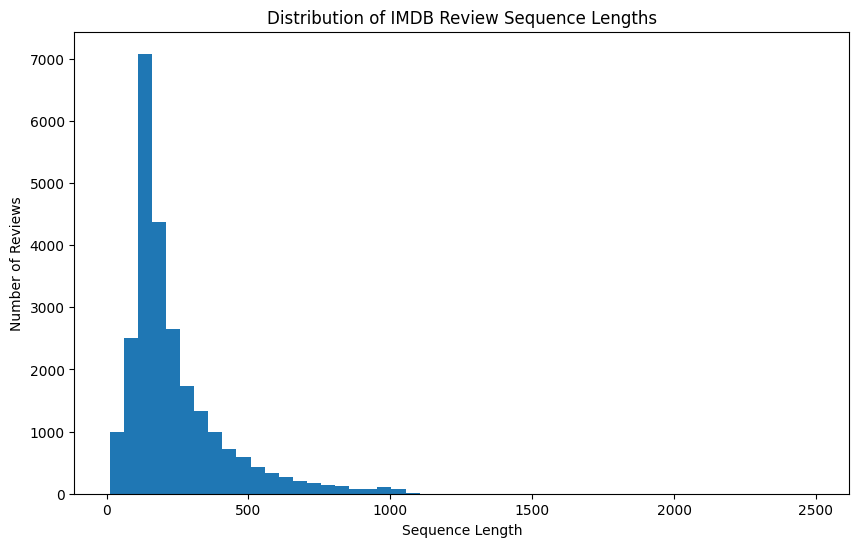

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(train_lengths, bins=50)

plt.xlabel("Sequence Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of IMDB Review Sequence Lengths")

plt.show()

### Pad the sequences

In [13]:
X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding="pre",
    truncating="pre"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding="pre",
    truncating="pre"
)

In [14]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


### Verify labels

In [15]:
print("Unique training labels:", np.unique(y_train))
print("Unique testing labels:", np.unique(y_test))

Unique training labels: [0 1]
Unique testing labels: [0 1]


### Check class distribution

In [16]:
unique, counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": unique,
    "Count": counts
})

class_distribution

,Class,Count
0,0,12500
1,1,12500


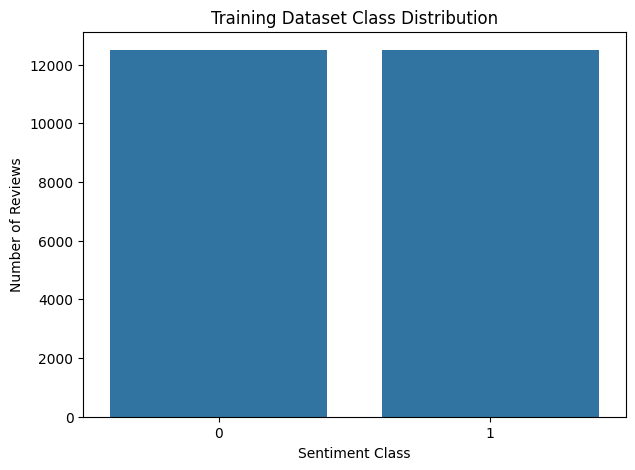

In [17]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=class_distribution,
    x="Class",
    y="Count"
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")

plt.show()

### Understand the model architecture

### RNN

``` text
Embedding
    ↓
SimpleRNN(64)
    ↓
Dropout
    ↓
Dense(1, sigmoid)

### LSTM

``` text
Embedding
    ↓
LSTM(64)
    ↓
Dropout
    ↓
Dense(1, sigmoid)

### GRU

``` text
Embedding
    ↓
GRU(64)
    ↓
Dropout
    ↓
Dense(1, sigmoid)

### Create a model-building function

## 5. Model Architecture

Three sequence classification models are implemented:

1. Simple Recurrent Neural Network (RNN)
2. Long Short-Term Memory (LSTM)
3. Gated Recurrent Unit (GRU)

To ensure a fair comparison, all models use the same vocabulary size, embedding dimension, number of recurrent units, dropout rate, optimizer, loss function, batch size, and number of epochs. Only the recurrent layer is changed.

## RNN model

In [29]:
def build_rnn_model():

    model = Sequential([
        Embedding(
            input_dim=NUM_WORDS,
            output_dim=EMBEDDING_DIM
        ),

        SimpleRNN(HIDDEN_UNITS),

        Dropout(0.5),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.build(input_shape=(None, MAX_LEN))

    return model

In [30]:
rnn_model = build_rnn_model()

In [31]:
rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
Dense(1, activation="sigmoid")

<Dense name=dense_5, built=False>

## LSTM model

In [33]:
def build_lstm_model():

    model = Sequential([
        Embedding(
            input_dim=NUM_WORDS,
            output_dim=EMBEDDING_DIM
        ),

        LSTM(HIDDEN_UNITS),

        Dropout(0.5),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.build(input_shape=(None, MAX_LEN))

    return model

In [34]:
lstm_model = build_lstm_model()

In [35]:
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

## GRU model

In [36]:
def build_gru_model():

    model = Sequential([
        Embedding(
            input_dim=NUM_WORDS,
            output_dim=EMBEDDING_DIM
        ),

        GRU(HIDDEN_UNITS),

        Dropout(0.5),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.build(input_shape=(None, MAX_LEN))

    return model

In [37]:
gru_model = build_gru_model()

In [38]:
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

### Compare model parameters

In [39]:
model_parameters = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

model_parameters

,Model,Parameters
0,RNN,1292417
1,LSTM,1329473
2,GRU,1317313


### Add EarlyStopping

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

In [41]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

The validation loss stopped improving.

Early stopping can stop training instead of continuing unnecessarily.

restore_best_weights=True means the model returns to the weights from the best validation-loss epoch.

## 6. Training the RNN Model

The RNN model is trained using the training dataset with 20% of the training data reserved for validation.

In [50]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [51]:
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

rnn_training_time = time.time() - start_time

print(f"RNN training time: {rnn_training_time:.2f} seconds")

rnn_epochs_completed = len(rnn_history.history["loss"])

print("RNN epochs completed:", rnn_epochs_completed)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9833 - loss: 0.0598 - val_accuracy: 0.7366 - val_loss: 0.7494
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9550 - loss: 0.1170 - val_accuracy: 0.6208 - val_loss: 1.0470
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9586 - loss: 0.1087 - val_accuracy: 0.7118 - val_loss: 0.8778
RNN training time: 17.16 seconds
RNN epochs completed: 3


### Examine RNN training history

In [52]:
print(rnn_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## 7. Training the LSTM Model

The LSTM model uses the same dataset, preprocessing, optimizer, batch size, validation split, maximum number of epochs, and stopping criteria as the RNN model.

In [53]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [54]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

lstm_training_time = time.time() - start_time

print(f"LSTM training time: {lstm_training_time:.2f} seconds")

lstm_epochs_completed = len(lstm_history.history["loss"])

print("LSTM epochs completed:", lstm_epochs_completed)

Epoch 1/5


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9309 - loss: 0.1878 - val_accuracy: 0.8686 - val_loss: 0.3681
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9258 - loss: 0.2000 - val_accuracy: 0.8630 - val_loss: 0.4259
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9460 - loss: 0.1504 - val_accuracy: 0.8558 - val_loss: 0.4968
LSTM training time: 9.76 seconds
LSTM epochs completed: 3


## 8. Training the GRU Model

The GRU model is trained using the same experimental configuration as the RNN and LSTM models.

In [55]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [56]:
start_time = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

gru_training_time = time.time() - start_time

print(f"GRU training time: {gru_training_time:.2f} seconds")

gru_epochs_completed = len(gru_history.history["loss"])

print("GRU epochs completed:", gru_epochs_completed)

Epoch 1/5


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8950 - loss: 0.2653 - val_accuracy: 0.8632 - val_loss: 0.3240
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9162 - loss: 0.2232 - val_accuracy: 0.8114 - val_loss: 0.4116
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9291 - loss: 0.1901 - val_accuracy: 0.8038 - val_loss: 0.4393
GRU training time: 10.08 seconds
GRU epochs completed: 3


### Create a training summary

In [57]:
training_summary = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Training Time (seconds)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ],
    "Epochs Completed": [
        rnn_epochs_completed,
        lstm_epochs_completed,
        gru_epochs_completed
    ],
    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

training_summary

,Model,Training Time (seconds),Epochs Completed,Parameters
0,RNN,17.162397,3,1292417
1,LSTM,9.763244,3,1329473
2,GRU,10.082829,3,1317313


### Import evaluation metrics

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Generate predictions

In [61]:
rnn_prob = rnn_model.predict(X_test, verbose=0)
lstm_prob = lstm_model.predict(X_test, verbose=0)
gru_prob = gru_model.predict(X_test, verbose=0)

In [62]:
rnn_pred = (rnn_prob >= 0.5).astype(int).ravel()
lstm_pred = (lstm_prob >= 0.5).astype(int).ravel()
gru_pred = (gru_prob >= 0.5).astype(int).ravel()

In [66]:
print(rnn_pred)
print(lstm_pred)
print(gru_pred)

[1 1 0 ... 1 0 1]
[0 1 1 ... 0 0 1]
[0 1 1 ... 0 0 0]


### Calculate Evaluation Metrics

In [ ]:
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

In [68]:
rnn_metrics = evaluate_model(y_test, rnn_pred)
lstm_metrics = evaluate_model(y_test, lstm_pred)
gru_metrics = evaluate_model(y_test, gru_pred)

In [69]:
metrics_comparison = pd.DataFrame(
    [rnn_metrics, lstm_metrics, gru_metrics],
    index=["RNN", "LSTM", "GRU"]
)

metrics_comparison

,Accuracy,Precision,Recall,F1-Score
RNN,0.73452,0.743137,0.71680,0.729731
LSTM,0.85968,0.874854,0.83944,0.856781
GRU,0.85984,0.858921,0.86112,0.860019


## Classification Reports

### RNN

In [70]:
print("========== RNN CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        rnn_pred,
        target_names=["Negative", "Positive"]
    )
)

========== RNN CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

    Negative       0.73      0.75      0.74     12500
    Positive       0.74      0.72      0.73     12500

    accuracy                           0.73     25000
   macro avg       0.73      0.73      0.73     25000
weighted avg       0.73      0.73      0.73     25000



### LSTM

In [71]:
print("========== LSTM CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        lstm_pred,
        target_names=["Negative", "Positive"]
    )
)

========== LSTM CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

    Negative       0.85      0.88      0.86     12500
    Positive       0.87      0.84      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



### GRU

In [72]:
print("========== GRU CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        gru_pred,
        target_names=["Negative", "Positive"]
    )
)

========== GRU CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86     12500
    Positive       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



### Confusion Matrices

In [73]:
rnn_cm = confusion_matrix(y_test, rnn_pred)
lstm_cm = confusion_matrix(y_test, lstm_pred)
gru_cm = confusion_matrix(y_test, gru_pred)

print("RNN Confusion Matrix:")
print(rnn_cm)

print("\nLSTM Confusion Matrix:")
print(lstm_cm)

print("\nGRU Confusion Matrix:")
print(gru_cm)

RNN Confusion Matrix:
[[9403 3097]
 [3540 8960]]

LSTM Confusion Matrix:
[[10999  1501]
 [ 2007 10493]]

GRU Confusion Matrix:
[[10732  1768]
 [ 1736 10764]]


In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

### RNN

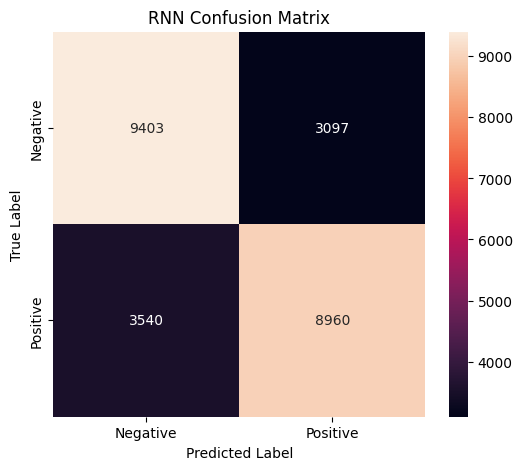

In [75]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### LSTM

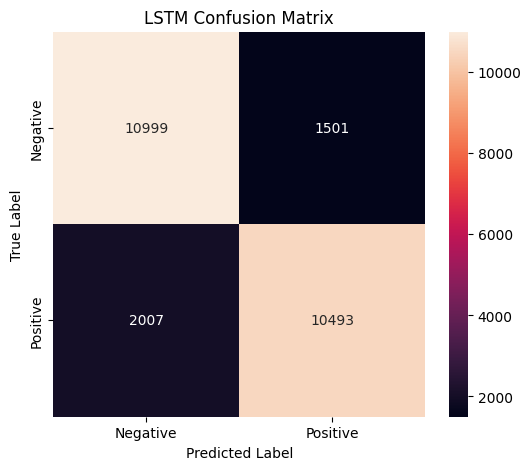

In [76]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### GRU

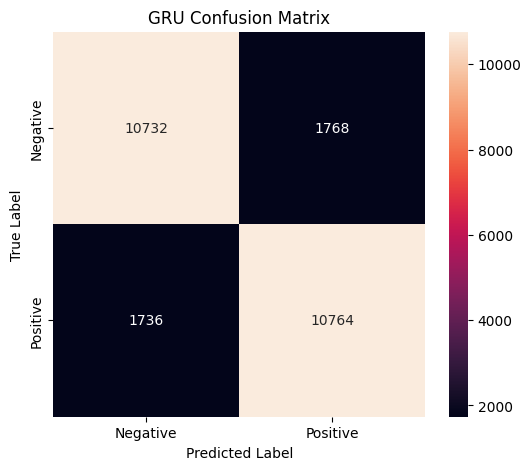

In [77]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    gru_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Advantages and Limitations

### Advantages

- **RNN:** Simple architecture with fewer parameters and relatively low computational complexity. It provides a useful baseline for sequence classification.
- **LSTM:** Uses memory cells and gates to retain relevant information over longer sequences, making it suitable for learning long-term dependencies.
- **GRU:** Uses a simpler gated architecture than LSTM while still being able to capture long-term dependencies. This can provide a useful balance between model complexity and sequence-learning capability.
- **Fair comparison:** All three models were trained using the same dataset, vocabulary size, sequence length, embedding dimension, hidden units, optimizer, dropout, batch size, and training configuration. Therefore, the recurrent architecture was the primary variable being compared.
- **Multiple evaluation metrics:** Accuracy, precision, recall, F1-score, confusion matrices, validation performance, training time, and parameter count provide a broader comparison than accuracy alone.

### Limitations

- **Dataset limitation:** The experiment uses only the IMDB movie-review dataset, so the observed performance may not directly generalize to other types of text or sequence-classification tasks.
- **Sequence length limitation:** Reviews were padded/truncated to a maximum length of 200 tokens. Information beyond this length may therefore be lost.
- **Vocabulary limitation:** Only the 10,000 most frequent words were considered. Less frequent words are treated as out-of-vocabulary tokens.
- **Limited training:** The models were trained for a maximum of 5 epochs with early stopping. Longer training or additional hyperparameter tuning could produce different results.
- **Single experimental configuration:** The comparison uses one set of hyperparameters. Different embedding dimensions, hidden units, dropout rates, learning rates, or batch sizes could change the relative performance.
- **Computational dependency:** Training time depends on the available hardware and software environment, so the measured training times are specific to this experimental setup.

## Conclusion

In this experiment, SimpleRNN, LSTM, and GRU models were implemented and evaluated for binary sequence classification using the IMDB movie-review dataset. All three models followed the same overall experimental configuration so that their classification performance, computational complexity, and training behavior could be compared fairly.

The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrices. In addition, the number of parameters and training time were compared to study the computational requirements of each architecture.

The experiment demonstrates the differences between basic recurrent and gated recurrent architectures for sequence classification. RNN provides a simple baseline, while LSTM and GRU introduce gating mechanisms that are designed to handle information over longer sequences.

Overall, the experiment provides a practical understanding of RNN, LSTM, and GRU architectures, confusion matrices, parameter counts, and training time can be used together to analyze sequence-classification models.